In [1]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)
path = "/content/drive/MyDrive/projet/"

Mounted at /content/drive/


In [2]:

import json

with open('/content/drive/MyDrive/projet/test_videodatainfo/test_videodatainfo.json', 'r') as file:
    data_test = json.load(file)

for key, item in data_test.items():
    print(key)

info
videos
sentences


In [3]:

# on doit fusionner les deux listes 'sentences' et 'videos' sur la clé 'video_id'ArithmeticError
sentences = data_test['sentences']
videos = data_test['videos']

test = []

# Crée un index pour aller plus vite dans videos
dict_videos = {d['video_id']: d for d in videos}

for d1 in sentences:
    vid = d1['video_id']
    # On fait une copie pour ne pas modifier d1 directement
    fusion_donnees = d1.copy()
    # Si on trouve le même video_id dans la 2e liste, on ajoute ses clés
    if vid in dict_videos:
        fusion_donnees.update(dict_videos[vid])
    # On ajoute le résultat à la liste finale
    test.append(fusion_donnees)

In [4]:

with open('/content/drive/MyDrive/projet/train_val_annotation/train_val_videodatainfo.json', 'r') as file:
    data_train = json.load(file)

In [5]:

# fusion des données

# on doit fusionner les deux listes 'sentences' et 'videos' sur la clé 'video_id'ArithmeticError
sentences = data_train['sentences']
videos = data_train['videos']

train = []

# Crée un index pour aller plus vite dans videos
dict_videos = {d['video_id']: d for d in videos}

for d1 in sentences:
    vid = d1['video_id']
    # On fait une copie pour ne pas modifier d1 directement
    fusion_donnees = d1.copy()
    # Si on trouve le même video_id dans la 2e liste, on ajoute ses clés
    if vid in dict_videos:
        fusion_donnees.update(dict_videos[vid])
    # On ajoute le résultat à la liste finale
    train.append(fusion_donnees)

In [6]:
print(f"taille de train, {len(train)}, taille ddu test {len(test)}")

taille de train, 140200, taille ddu test 59800


Séparation en Train et Validation

In [7]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train,
    test_size=0.2,
    stratify=[d["category"] for d in train],
    random_state=42
)

print(f"Taille train: {len(train_data)}, validation: {len(val_data)}")
train, val = train_data, val_data

Taille train: 112160, validation: 28040


### Association des captions avec les catégories correspondantes

In [8]:
all_labels = sorted(list({d['category'] for d in train_data}))
label2id = {lab: i for i, lab in enumerate(all_labels)}
id2label = {i: lab for lab, i in label2id.items()}

for d in train_data:
    d['category'] = label2id[d['category']]
for d in val_data:
    d['category'] = label2id[d['category']]

Configuration des hyperparamètres

In [9]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AlbertModel, AlbertTokenizerFast, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


# Pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Hyperparamètres principaux
MODEL_NAME = "albert-large-v2"  # ou "albert-base-v2"
MAX_LEN = 128
BATCH_SIZE = 64
LR = 5e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 10
DROPOUT = 0.4


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dossiers de sauvegarde
SAVE_DIR = "./checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_model.pt")

aggregate_by_video = True  # False si on veut garder plusieurs captions par video


### Nouveau traitement sur le Dataset adapté au modèle

In [10]:
# Traitement du Dataset pour s'adapter au modèle

def make_dataset(items, tokenizer, max_len=128, aggregate_by_video=False):
    """Transforme les données brutes en TensorDataset"""

    texts, labels = [], []

    if aggregate_by_video:
        vid2texts, vid2label = {}, {}
        for d in items:
            vid = d.get("video_id", f"no_vid_{len(vid2texts)}")
            vid2texts.setdefault(vid, []).append(d.get("caption", ""))
            vid2label[vid] = d.get("category", None)
        for vid in vid2texts:
            texts.append(" [SEP] ".join(vid2texts[vid]))
            labels.append(vid2label[vid])
    else:
        texts = [d.get("caption", "") for d in items]
        labels = [d.get("category", None) for d in items]

    toks = tokenizer(
        texts,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    return TensorDataset(
        toks["input_ids"],
        toks["attention_mask"],
        torch.tensor(labels, dtype=torch.long)
    )



## Le modèle

In [11]:
class AttentionPooling(nn.Module):
    """
    Pooling basé sur une attention simple :
    calcule un poids d'attention pour chaque token,
    puis fait une moyenne pondérée des embeddings.
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, hidden_states, mask=None):
        # Calcul des scores d'attention
        scores = self.attn(hidden_states).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)

        # Moyenne pondérée des états cachés
        context = torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)
        return context


class AlbertClassifier(nn.Module):
    """
    Modèle de classification :
    - Albert (encoder de texte)
    - AttentionPooling sur les tokens
    - Fusion [CLS] + contexte moyen
    - Classifieur linéaire
    """
    def __init__(self, model_name, n_classes, dropout_prob=0.4):
        super().__init__()
        self.albert = AlbertModel.from_pretrained(model_name)
        hidden_size = self.albert.config.hidden_size

        # Module d’attention et classifieur
        self.attn_pool = AttentionPooling(hidden_size)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_size, n_classes)
        )


    def forward(self, input_ids, attention_mask):
        # Encodage avec ALBERT
        outputs = self.albert(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        last_hidden = outputs.last_hidden_state

        # Représentation du token [CLS]
        cls_emb = last_hidden[:, 0, :]

        # Pooling attention sur tous les tokens
        pooled = self.attn_pool(last_hidden, mask=attention_mask)

        # Fusion des deux représentations
        combined = torch.cat([cls_emb, pooled], dim=1)

        # Prédiction finale
        logits = self.fc(combined)
        return logits


## Boucle d'entraînement

In [12]:
# Tokenizer et datasets
tokenizer = AlbertTokenizerFast.from_pretrained(MODEL_NAME)
train_ds = make_dataset(train_data, tokenizer, MAX_LEN, aggregate_by_video)
val_ds = make_dataset(val_data, tokenizer, MAX_LEN, aggregate_by_video)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Modèle + optimiseur + scheduler
model = AlbertClassifier(MODEL_NAME, n_classes=20).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

# Boucle d'entraînement
for epoch in range(NUM_EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{NUM_EPOCHS} =====")

    # mode entrainement
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for input_ids, attention_mask, labels in train_loader:
        input_ids, attention_mask, labels = input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = nn.CrossEntropyLoss()(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item() * input_ids.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)
    train_acc = correct / total
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # Evaluation sur les données de validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids, attention_mask, labels = input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)
            logits = model(input_ids, attention_mask)
            loss = nn.CrossEntropyLoss()(logits, labels)
            val_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = correct / total
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% | LR: {scheduler.get_last_lr()[0]:.2e}")

    # Sauvegarde du meilleur modèle
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"Nouveau meilleur modèle sauvegardé ({best_val_acc*100:.2f}%)")

print(f"\nEntraînement terminé. Meilleur Val Acc: {best_val_acc*100:.2f}%")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/71.5M [00:00<?, ?B/s]


===== Epoch 1/10 =====
Train Loss: 2.3913 | Val Loss: 1.8658
Train Acc: 32.00% | Val Acc: 48.11% | LR: 5.00e-05
Nouveau meilleur modèle sauvegardé (48.11%)

===== Epoch 2/10 =====
Train Loss: 1.5113 | Val Loss: 1.4732
Train Acc: 58.86% | Val Acc: 58.37% | LR: 4.44e-05
Nouveau meilleur modèle sauvegardé (58.37%)

===== Epoch 3/10 =====
Train Loss: 1.2549 | Val Loss: 1.3738
Train Acc: 65.22% | Val Acc: 61.27% | LR: 3.89e-05
Nouveau meilleur modèle sauvegardé (61.27%)

===== Epoch 4/10 =====
Train Loss: 1.0788 | Val Loss: 1.3046
Train Acc: 70.20% | Val Acc: 63.31% | LR: 3.33e-05
Nouveau meilleur modèle sauvegardé (63.31%)

===== Epoch 5/10 =====
Train Loss: 0.9345 | Val Loss: 1.2964
Train Acc: 73.88% | Val Acc: 64.21% | LR: 2.78e-05
Nouveau meilleur modèle sauvegardé (64.21%)

===== Epoch 6/10 =====
Train Loss: 0.7793 | Val Loss: 1.3287
Train Acc: 78.22% | Val Acc: 63.82% | LR: 2.22e-05

===== Epoch 7/10 =====
Train Loss: 0.6343 | Val Loss: 1.2965
Train Acc: 82.44% | Val Acc: 64.28% | LR

## Affichage des courbes d'apprentissage

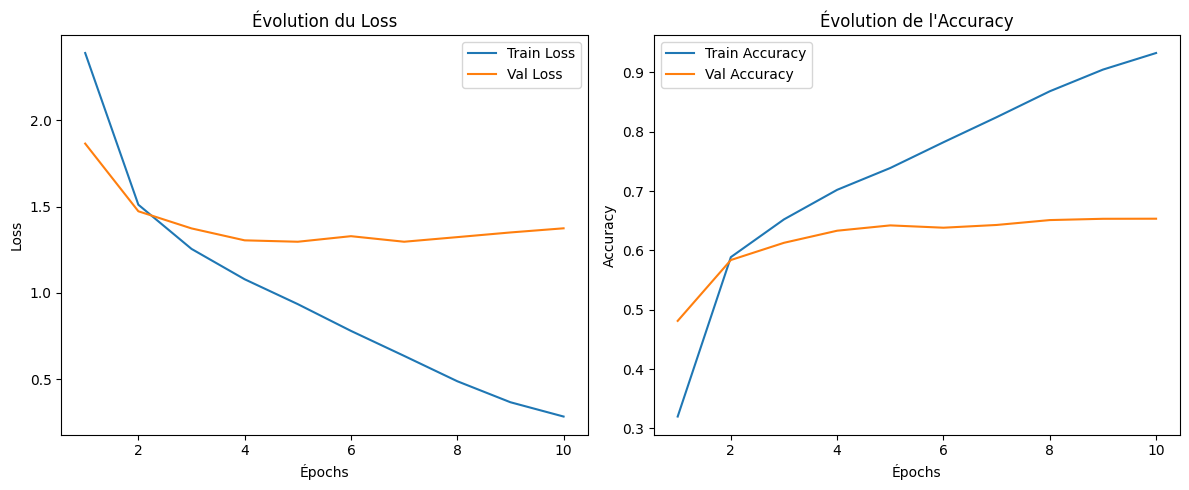

In [13]:
epochs = np.arange(1, NUM_EPOCHS + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.title("Évolution du Loss")
plt.xlabel("Épochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.title("Évolution de l'Accuracy")
plt.xlabel("Épochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Evaluation sur l'ensemble de Test

In [14]:
# chargement des données de Test

test_ds = make_dataset(test, tokenizer, MAX_LEN, aggregate_by_video)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


---- Rapport de classification ----
                      precision    recall  f1-score   support

               music     0.5983    0.6062    0.6022       226
              people     0.2593    0.1772    0.2105        79
              gaming     0.7415    0.7730    0.7569       141
      sports/actions     0.8182    0.8056    0.8118       324
news/events/politics     0.5800    0.6350    0.6063       137
           education     0.5278    0.5135    0.5205        74
            tv shows     0.4375    0.4545    0.4459        77
        movie/comedy     0.6646    0.7243    0.6932       301
           animation     0.6261    0.5902    0.6076       122
      vehicles/autos     0.8217    0.8689    0.8446       244
               howto     0.6154    0.6012    0.6082       173
              travel     0.6026    0.6267    0.6144        75
  science/technology     0.5682    0.5396    0.5535       139
        animals/pets     0.6524    0.7176    0.6835       170
         kids/family     0.6075 

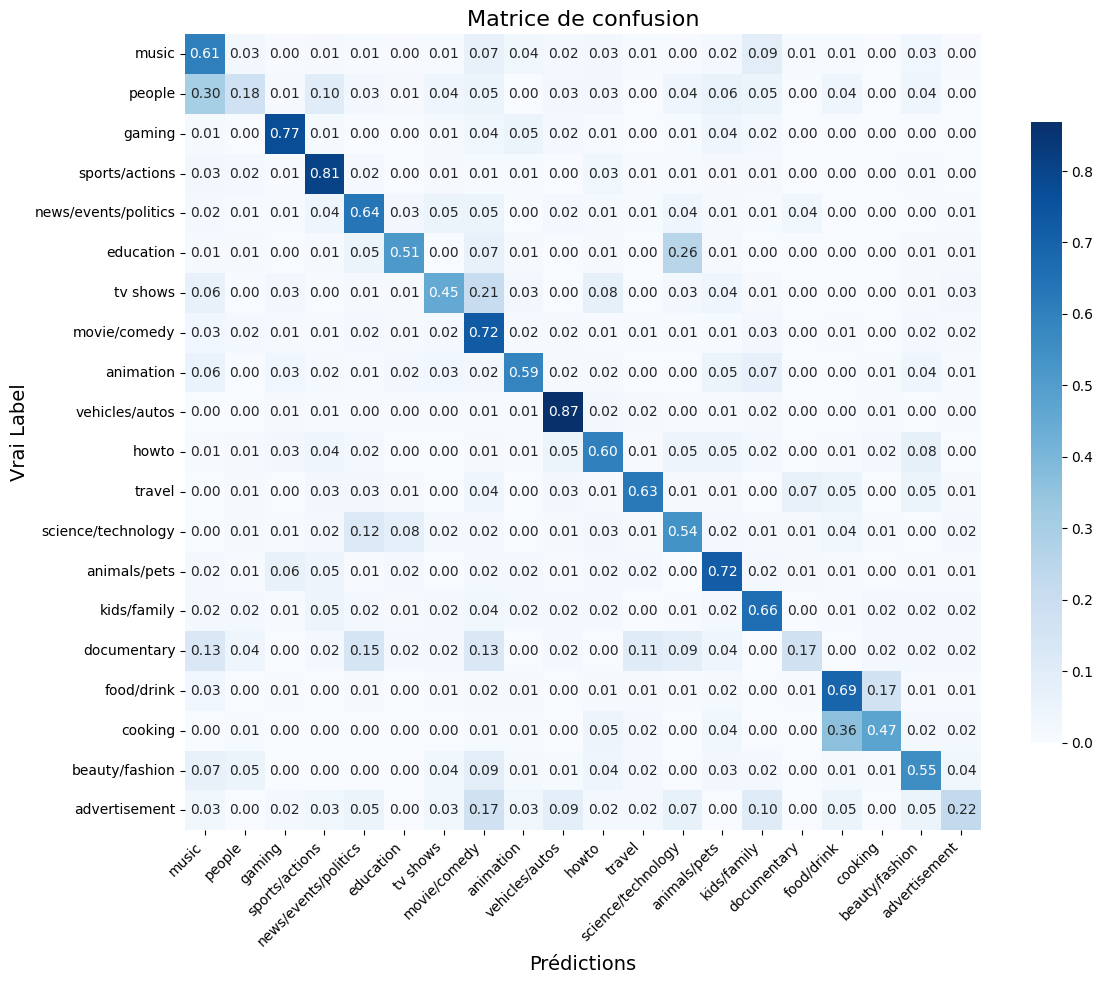

In [15]:
# === Évaluation sur le jeu de test ===
import seaborn as sns

labels_map = {
    0: "music",
    1: "people",
    2: "gaming",
    3: "sports/actions",
    4: "news/events/politics",
    5: "education",
    6: "tv shows",
    7: "movie/comedy",
    8: "animation",
    9: "vehicles/autos",
    10: "howto",
    11: "travel",
    12: "science/technology",
    13: "animals/pets",
    14: "kids/family",
    15: "documentary",
    16: "food/drink",
    17: "cooking",
    18: "beauty/fashion",
    19: "advertisement"
}

# Évaluation du modèle
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
preds, trues = [], []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids, attention_mask, labels = input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)
        logits = model(input_ids, attention_mask)
        batch_preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()
        preds.extend(batch_preds)
        trues.extend(labels.cpu().numpy().tolist())

# Rapport de classification
report = classification_report(trues, preds, target_names=[labels_map[i] for i in range(len(labels_map))], digits=4, zero_division=0)
print("\n---- Rapport de classification ----")
print(report)

# Matrice de confusion
cm = confusion_matrix(trues, preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[labels_map[i] for i in range(len(labels_map))],
    yticklabels=[labels_map[i] for i in range(len(labels_map))],
    square=True,
    cbar=True,
    cbar_kws={"shrink": 0.75}
)
plt.title("Matrice de confusion", fontsize=16)
plt.xlabel("Prédictions", fontsize=14)
plt.ylabel("Vrai Label", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
